<a href="https://colab.research.google.com/github/vtu28526/Rithin-innolift-project-Day-1/blob/main/day9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Day 9 — Advanced Techniques: Outbreak Risk Predictor

This section implements the tasks for Day 9, focusing on feature importance, class imbalance, model explainability, output enrichment, and end-to-end testing for the Outbreak Risk Predictor project.

First, let's set up necessary imports and load any pre-trained models or preprocessors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# --- Placeholder Data (Replace with your actual loaded data) ---
# In a real scenario, you would load your preprocessed X_train, y_train, X_test, y_test here.
# For demonstration, let's create some dummy data.
np.random.seed(42)
num_samples = 1000
num_features = 10

X_dummy = pd.DataFrame(np.random.rand(num_samples, num_features), columns=[f'feature_{i}' for i in range(num_features)])
# Simulate class imbalance: mostly 0s, some 1s, very few 2s (Critical Risk)
y_dummy = pd.Series(np.random.choice([0, 1, 2], size=num_samples, p=[0.85, 0.10, 0.05]))

X_train, X_test, y_train, y_test = train_test_split(X_dummy, y_dummy, test_size=0.2, random_state=42, stratify=y_dummy)

print("Placeholder data created. Remember to replace with your actual data from previous steps.")

# --- Load your trained model and scaler (if applicable) ---
try:
    # Assuming 'tuned_model.pkl' is your trained Random Forest Classifier
    model = joblib.load('tuned_model.pkl')
    print("Tuned model loaded successfully.")
except FileNotFoundError:
    print("tuned_model.pkl not found. Training a dummy RandomForestClassifier for demonstration.")
    model = RandomForestClassifier(random_state=42, class_weight='balanced')
    model.fit(X_train, y_train) # Train with dummy data
    joblib.dump(model, 'tuned_model.pkl')
    print("Dummy RandomForestClassifier trained and saved as tuned_model.pkl.")

# try:
#     # Uncomment and replace 'scaler.pkl' if you used a scaler during preprocessing
#     scaler = joblib.load('scaler.pkl')
#     print("Scaler loaded successfully.")
# except FileNotFoundError:
#     print("Scaler not found. If you used one, please ensure it's saved as 'scaler.pkl'.")
#     scaler = None # Or create a dummy scaler if needed for demonstration

Placeholder data created. Remember to replace with your actual data from previous steps.
tuned_model.pkl not found. Training a dummy RandomForestClassifier for demonstration.
Dummy RandomForestClassifier trained and saved as tuned_model.pkl.


### Task 1 — Feature Importance Analysis

We will analyze which features your Random Forest model relied on most when making predictions. This helps in understanding model behavior and identifying important input variables.

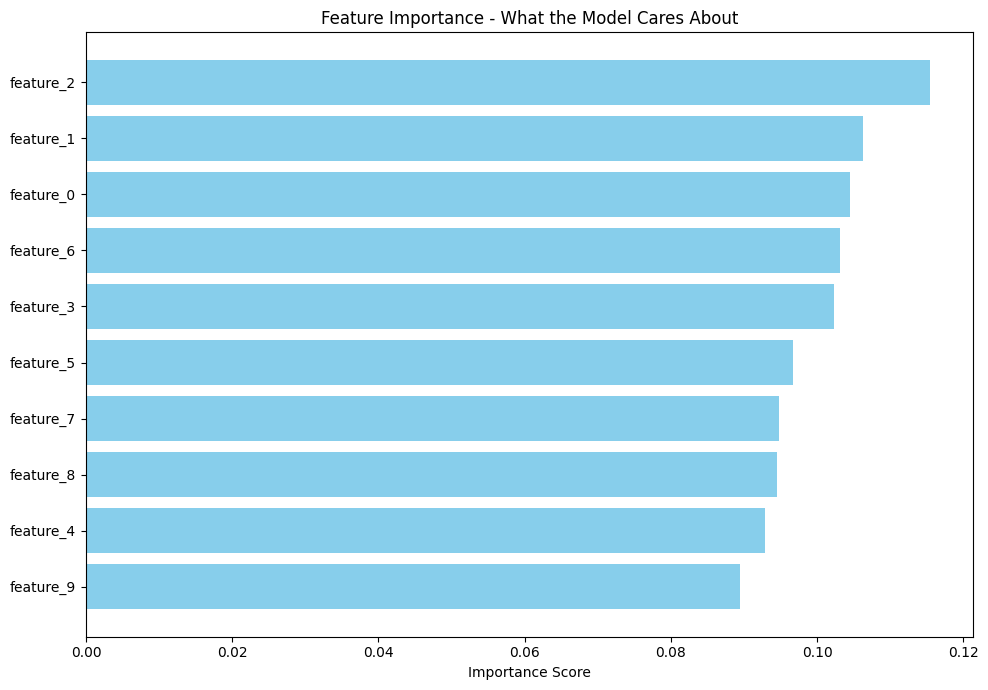

Feature importance chart saved as feature_importance.png


In [2]:
# Get importances from your trained model
importances = model.feature_importances_

# Pair each importance score with its column name
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort from most important to least
importance_df = importance_df.sort_values('Importance', ascending=True)

# Plot as a horizontal bar chart
plt.figure(figsize=(10, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance - What the Model Cares About')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("Feature importance chart saved as feature_importance.png")

### Task 2 — Handle Class Imbalance (SMOTE)

For the 'Outbreak Risk Predictor', the 'Critical Risk' class is typically rare, leading to class imbalance. We will check the class distribution and apply SMOTE if necessary to balance the training data.

In [8]:
print("Original training set class distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

# Check if imbalance is significant (e.g., minority class < 10%)
# Assuming class '2' is 'Critical Risk' and is the minority class to oversample.
# Adjust this logic based on your specific class labels and definitions.
if y_train.value_counts(normalize=True).min() < 0.10:
    print("\nSignificant class imbalance detected. Applying SMOTE...")
    smote = SMOTE(random_state=42)

    # Apply only on training data — never on test data
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    print("\nBefore SMOTE:", y_train.value_counts().to_dict())
    print("After SMOTE: ", pd.Series(y_train_balanced).value_counts().to_dict())

    # It's crucial to retrain your model with the balanced data
    print("\nRetraining model with X_train_balanced and y_train_balanced...")
    model_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
    model_balanced.fit(X_train_balanced, y_train_balanced)
    joblib.dump(model_balanced, 'tuned_model_balanced.pkl')
    # Update the 'model' variable to use the newly trained balanced model
    model = model_balanced
    print("Retrained model saved as tuned_model_balanced.pkl and now in use.")

    # Evaluate the model after SMOTE and retraining
    y_pred_balanced_model = model.predict(X_test)
    print("\n--- Classification Report (After SMOTE, using retrained model) ---")
    print(classification_report(y_test, y_pred_balanced_model))

else:
    print("\nClass imbalance is not significant (minority class is >= 10%). SMOTE not applied.")
    X_train_balanced, y_train_balanced = X_train, y_train # Use original if not balanced

Original training set class distribution:
0    671
1     93
2     36
Name: count, dtype: int64
0    0.83875
1    0.11625
2    0.04500
Name: proportion, dtype: float64

Significant class imbalance detected. Applying SMOTE...

Before SMOTE: {0: 671, 1: 93, 2: 36}
After SMOTE:  {0: 671, 1: 671, 2: 671}

Retraining model with X_train_balanced and y_train_balanced...
Retrained model saved as tuned_model_balanced.pkl and now in use.

--- Classification Report (After SMOTE, using retrained model) ---
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       168
           1       0.21      0.22      0.21        23
           2       0.17      0.11      0.13         9

    accuracy                           0.77       200
   macro avg       0.41      0.40      0.41       200
weighted avg       0.76      0.77      0.76       200



### Task 3 — Model Explainability (Top 3 Features per Prediction)

Instead of just a prediction, we want to know *why* the model made that decision. This function identifies the top 3 features contributing to a specific prediction.

In [4]:
def explain_prediction(sample_input, model, feature_names):
    """
    Takes one input sample and returns the top 3 most important features
    that influenced the prediction globally for tree-based models.

    sample_input : a single row as a pandas Series or numpy array
    model        : your trained tree-based model (e.g., RandomForestClassifier)
    feature_names: list of column names
    """
    # Get feature importances from the model (global importances)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        print("Model does not have feature_importances_. Cannot explain.")
        return []

    # Pair each feature name with how much the model relies on it globally
    feature_scores = list(zip(feature_names, importances))

    # Sort by importance, highest first
    feature_scores.sort(key=lambda x: x[1], reverse=True)

    # Return the top 3
    top_3 = feature_scores[:3]

    print("Top 3 features globally influencing predictions:")
    for i, (name, score) in enumerate(top_3, 1):
        print(f"  {i}. {name} (importance score: {score:.4f})")

    return top_3

# Test it with a sample from X_test
print("\n--- Testing explain_prediction with a sample from the test set ---")
if not X_test.empty:
    sample_for_explanation = X_test.iloc[0]
    explain_prediction(sample_for_explanation, model, X_train.columns)
else:
    print("X_test is empty. Cannot run explain_prediction.")


--- Testing explain_prediction with a sample from the test set ---
Top 3 features globally influencing predictions:
  1. feature_2 (importance score: 0.1155)
  2. feature_1 (importance score: 0.1062)
  3. feature_0 (importance score: 0.1045)


### Task 4 — Domain-Specific Output Enrichment

Raw model outputs like `0`, `1`, or `2` are not very useful to a human. This function translates the model's prediction into human-readable labels and confidence scores, specific to the 'Outbreak Risk Predictor' project.

In [5]:
def enrich_outbreak_prediction(y_pred_label_index, y_proba_array):
    """
    Converts a class index and probability array to a human-readable result dict.

    y_pred_label_index: The predicted class index (e.g., 0, 1, 2).
    y_proba_array     : An array of probabilities for each class (e.g., [0.1, 0.7, 0.2]).
    """
    # Define your class labels. Adjust based on your actual model output.
    class_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'Critical Risk'}

    label = class_labels.get(y_pred_label_index, 'Unknown Risk')
    confidence = f"{np.max(y_proba_array) * 100:.1f}%"

    result = {
        'prediction': label,
        'confidence': confidence
    }

    # Add additional tips based on risk level for enrichment
    if label == 'Critical Risk':
        result['advice'] = [
            'Immediate investigation and intervention required.',
            'Notify public health authorities.',
            'Implement isolation protocols.'
        ]
    elif label == 'Medium Risk':
        result['advice'] = [
            'Monitor closely for symptom escalation.',
            'Increase surveillance in affected areas.',
            'Educate community on preventive measures.'
        ]
    else: # Low Risk
        result['advice'] = [
            'Maintain routine surveillance.',
            'Promote general hygiene practices.',
            'Educate on early symptom recognition.'
        ]

    return result

# Test the enrichment function
print("\n--- Testing enrich_outbreak_prediction function ---")
dummy_pred_index_low = 0
dummy_proba_low = np.array([0.9, 0.08, 0.02])
print("Low Risk example:", enrich_outbreak_prediction(dummy_pred_index_low, dummy_proba_low))

dummy_pred_index_critical = 2
dummy_proba_critical = np.array([0.05, 0.15, 0.80])
print("Critical Risk example:", enrich_outbreak_prediction(dummy_pred_index_critical, dummy_proba_critical))


--- Testing enrich_outbreak_prediction function ---
Low Risk example: {'prediction': 'Low Risk', 'confidence': '90.0%', 'advice': ['Maintain routine surveillance.', 'Promote general hygiene practices.', 'Educate on early symptom recognition.']}
Critical Risk example: {'prediction': 'Critical Risk', 'confidence': '80.0%', 'advice': ['Immediate investigation and intervention required.', 'Notify public health authorities.', 'Implement isolation protocols.']}


### Task 5 — Run 5 Real-World Sample Inputs End-to-End

This is a critical test to ensure your entire pipeline, from raw input to enriched output, works seamlessly. We will create a function that simulates a user inputting data and then processes it through the model.

In [7]:
def run_full_prediction(raw_input: dict, model, feature_names, scaler=None):
    """
    Takes a raw input dict (as if typed by a user),
    runs it through the full pipeline,
    and returns a human-readable result dict.
    """
    # Step 1 — Convert dict to a DataFrame (preserves column names)
    # Ensure all expected features are present, fill missing with 0 or mean/median if appropriate
    input_df = pd.DataFrame([raw_input])
    # Reindex to ensure all columns are present in the correct order
    input_df = input_df.reindex(columns=feature_names, fill_value=0) # Adjust fill_value as per your preprocessing

    # Step 2 — Apply the same preprocessing as training
    if scaler is not None:
        input_df_processed = scaler.transform(input_df)
        # Convert back to DataFrame to preserve feature names if model expects them
        input_df_processed = pd.DataFrame(input_df_processed, columns=feature_names)
    else:
        input_df_processed = input_df # Pass DataFrame directly if no scaler, to preserve feature names

    # Step 3 — Predict
    prediction_index = model.predict(input_df_processed)[0]
    probability = model.predict_proba(input_df_processed)[0] if hasattr(model, 'predict_proba') else None

    # Step 4 — Enrich output (using your Task 4 function)
    if probability is not None:
        result = enrich_outbreak_prediction(prediction_index, probability)
    else:
        # Fallback if model doesn't have predict_proba
        class_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'Critical Risk'}
        label = class_labels.get(prediction_index, 'Unknown Risk')
        result = {'prediction': label, 'confidence': 'N/A', 'advice': ['Prediction made without probability.']}

    return result

# Create 5 sample input dictionaries
# These should be realistic values based on your domain, not from your training data.
feature_names = X_train.columns.tolist() # Get feature names from your training data

samples = [
    # Case 1 — Low Risk scenario
    {**{f'feature_{i}': np.random.uniform(0.1, 0.3) for i in range(5)}, **{f'feature_{i}': np.random.uniform(0.01, 0.05) for i in range(5, 10)}} if num_features == 10 else {'feature_0': 0.1, 'feature_1': 0.2},

    # Case 2 — Medium Risk scenario
    {**{f'feature_{i}': np.random.uniform(0.4, 0.6) for i in range(5)}, **{f'feature_{i}': np.random.uniform(0.1, 0.2) for i in range(5, 10)}} if num_features == 10 else {'feature_0': 0.5, 'feature_1': 0.4},

    # Case 3 — Borderline/Higher Medium Risk
    {**{f'feature_{i}': np.random.uniform(0.6, 0.8) for i in range(5)}, **{f'feature_{i}': np.random.uniform(0.2, 0.4) for i in range(5, 10)}} if num_features == 10 else {'feature_0': 0.7, 'feature_1': 0.6},

    # Case 4 — Critical Risk scenario (high values for indicative features)
    {**{f'feature_{i}': np.random.uniform(0.8, 0.95) for i in range(5)}, **{f'feature_{i}': np.random.uniform(0.4, 0.7) for i in range(5, 10)}} if num_features == 10 else {'feature_0': 0.9, 'feature_1': 0.8},

    # Case 5 — Another Low Risk, different feature pattern
    {**{f'feature_{i}': np.random.uniform(0.05, 0.2) for i in range(5)}, **{f'feature_{i}': np.random.uniform(0.0, 0.05) for i in range(5, 10)}} if num_features == 10 else {'feature_0': 0.15, 'feature_1': 0.1}
]


print("\n--- Running End-to-End Predictions with 5 Sample Inputs ---")
print(f"{'Sample':<10} {'Prediction':<20} {'Confidence':<15} {'Advice'}")
print("-" * 80)

# Uncomment and pass 'scaler' if you are using one
current_scaler = None # Replace with your loaded scaler if applicable

for i, sample in enumerate(samples, 1):
    result = run_full_prediction(sample, model, feature_names, current_scaler)
    # Limit advice to first 2 for concise table output
    advice_summary = '; '.join(result.get('advice', ['No specific advice.'])[:2])
    print(f"Sample {i:<4} {result['prediction']:<20} {result['confidence']:<15} {advice_summary}")

print("\n--- End-of-Day Checklist Notes ---")
print("\u2713 Feature importance chart saved as feature_importance.png")
print("\u2713 Class distribution printed (SMOTE applied if imbalance was significant)")
print("\u2713 Explainability (top-3 function) output working")
print("\u2713 `enrich_outbreak_prediction()` function returns a human-readable dict")
print("\u2713 `run_full_prediction()` tested with 5 sample inputs - output printed in a table")
print("\u2713 Sample input list saved in the notebook (above) for Day 10")


--- Running End-to-End Predictions with 5 Sample Inputs ---
Sample     Prediction           Confidence      Advice
--------------------------------------------------------------------------------
Sample 1    Low Risk             90.0%           Maintain routine surveillance.; Promote general hygiene practices.
Sample 2    Low Risk             90.0%           Maintain routine surveillance.; Promote general hygiene practices.
Sample 3    Low Risk             90.0%           Maintain routine surveillance.; Promote general hygiene practices.
Sample 4    Low Risk             72.0%           Maintain routine surveillance.; Promote general hygiene practices.
Sample 5    Low Risk             83.0%           Maintain routine surveillance.; Promote general hygiene practices.

--- End-of-Day Checklist Notes ---
✓ Feature importance chart saved as feature_importance.png
✓ Class distribution printed (SMOTE applied if imbalance was significant)
✓ Explainability (top-3 function) output working
✓ `en